In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print("Shape:", df.shape)
print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

df.head()

Shape: (1000, 9)

Data Types
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [8]:
print(df.describe())

print("\nMean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nStandard Deviation")
print(df.std(numeric_only=True))
print(df.columns)

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
Transac

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
print(df["Date"].dtype)

datetime64[ns]


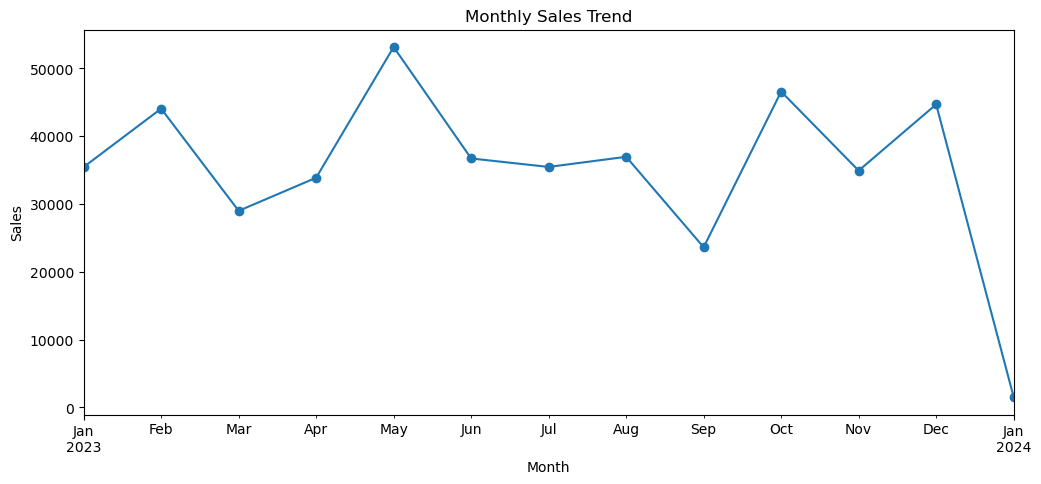

In [11]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales.plot(figsize=(12,5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

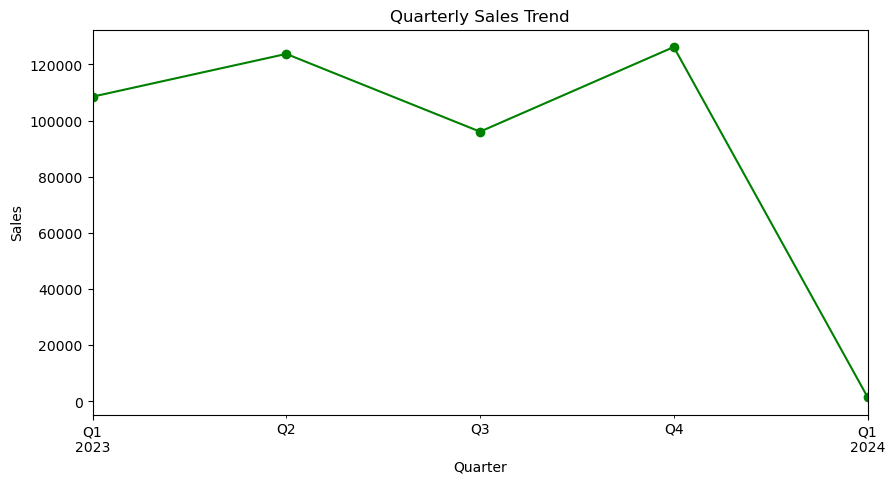

In [12]:
quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

quarterly_sales.plot(figsize=(10,5), marker="o", color="green")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

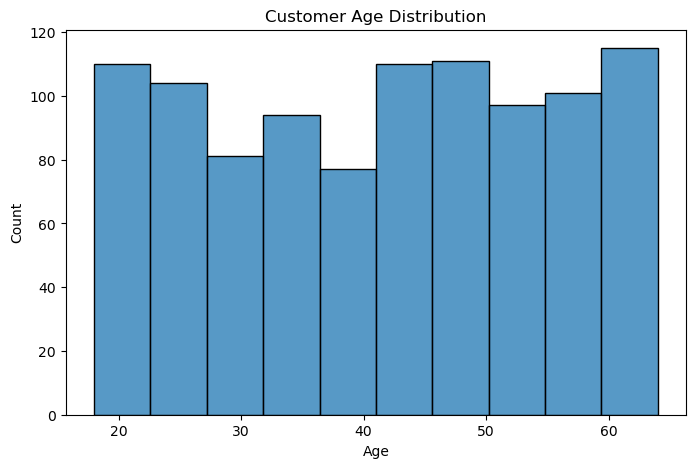

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10)

plt.title("Customer Age Distribution")
plt.show()

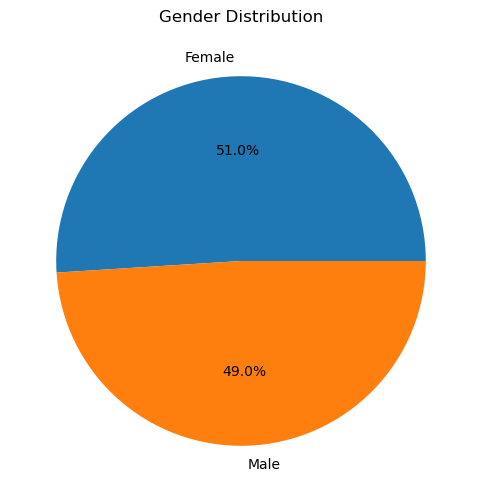

In [14]:
plt.figure(figsize=(6,6))

df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

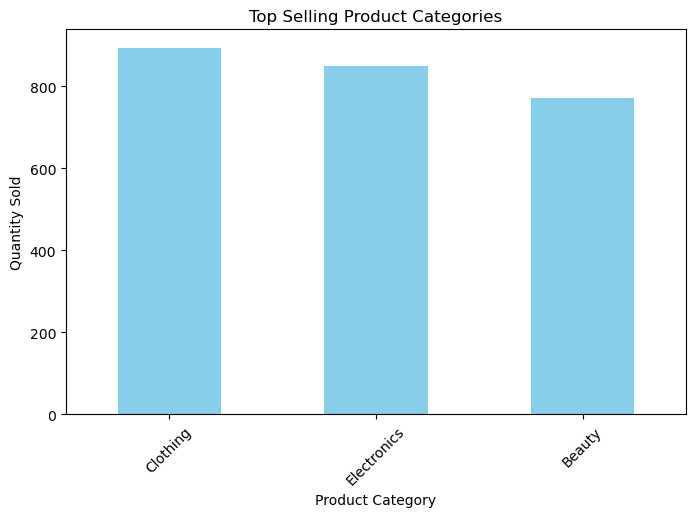

In [19]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
top_products.plot(kind="bar", color="skyblue")

plt.title("Top Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()
 

In [17]:
print(df.columns)
print(df.columns.tolist())

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


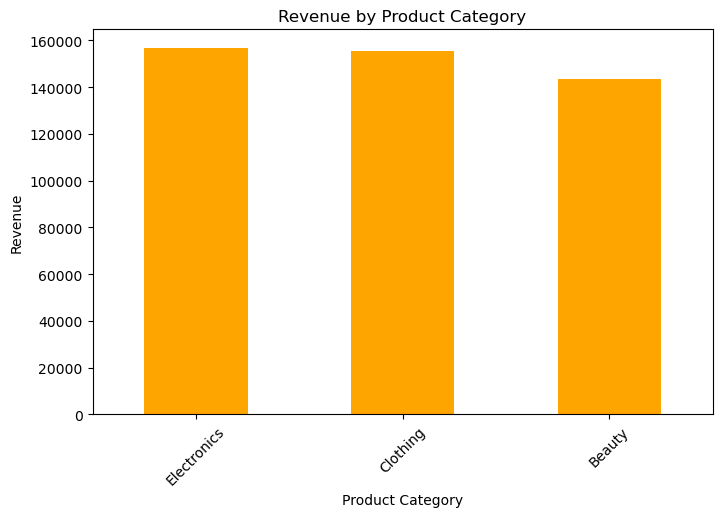

In [20]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar", color="orange")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

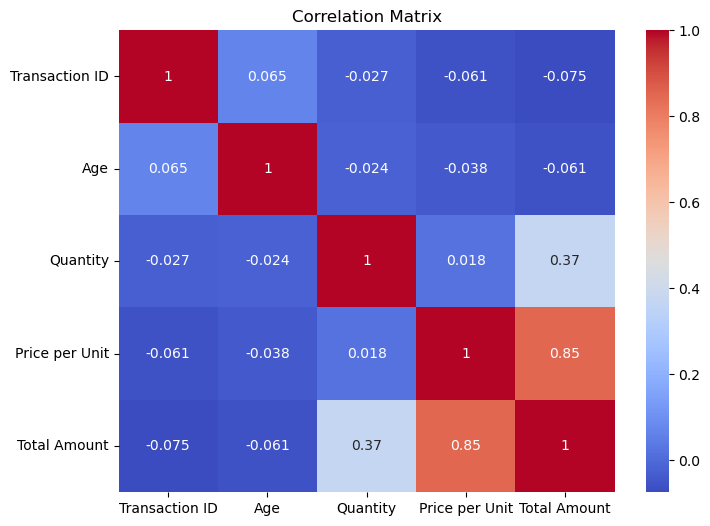

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

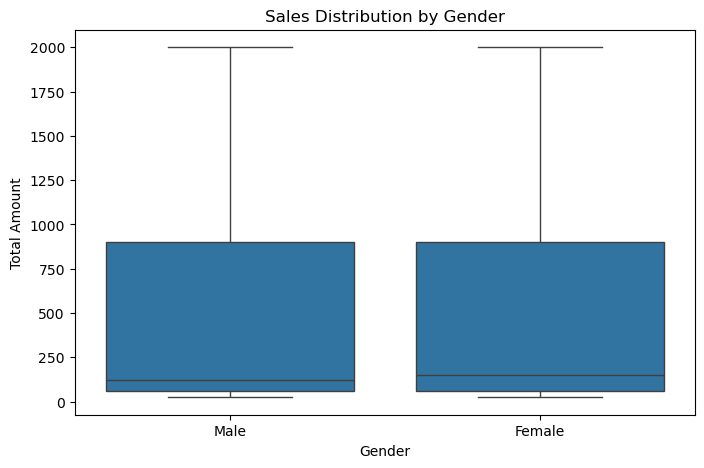

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Gender", y="Total Amount", data=df)

plt.title("Sales Distribution by Gender")

plt.show()

In [23]:
df.to_csv("Retail_Sales_EDA_Output.csv", index=False)

print("EDA Completed Successfully")

EDA Completed Successfully


In [24]:
customer = df.groupby("Customer ID").agg({
    "Quantity": "sum",
    "Total Amount": "sum",
    "Age": "mean"
}).reset_index()

customer.columns = ["Customer ID", "Frequency", "Monetary", "Age"]

customer.head()

,Customer ID,Frequency,Monetary,Age
0,CUST001,3,150,34.0
1,CUST002,2,1000,26.0
2,CUST003,1,30,50.0
3,CUST004,1,500,37.0
4,CUST005,2,100,30.0


In [25]:
print(customer.describe())

print("Average Purchase Value:", customer["Monetary"].mean())
print("Average Purchase Frequency:", customer["Frequency"].mean())

         Frequency     Monetary         Age
count  1000.000000  1000.000000  1000.00000
mean      2.514000   456.000000    41.39200
std       1.132734   559.997632    13.68143
min       1.000000    25.000000    18.00000
25%       1.000000    60.000000    29.00000
50%       3.000000   135.000000    42.00000
75%       4.000000   900.000000    53.00000
max       4.000000  2000.000000    64.00000
Average Purchase Value: 456.0
Average Purchase Frequency: 2.514


In [26]:
features = customer[["Frequency", "Monetary", "Age"]]

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

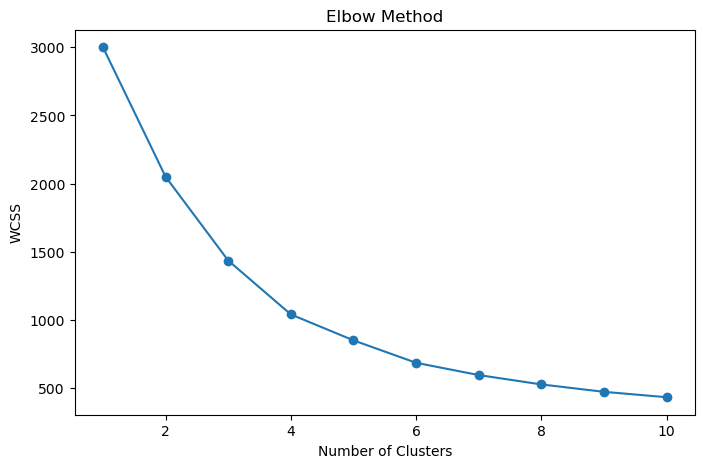

In [28]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer["Cluster"] = kmeans.fit_predict(scaled_features)

customer.head()

,Customer ID,Frequency,Monetary,Age,Cluster
0,CUST001,3,150,34.0,1
1,CUST002,2,1000,26.0,2
2,CUST003,1,30,50.0,3
3,CUST004,1,500,37.0,2
4,CUST005,2,100,30.0,2


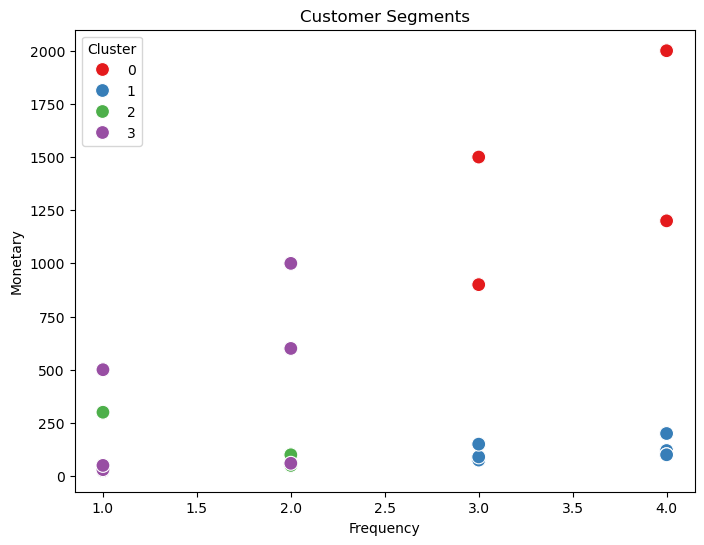

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments")
plt.show()

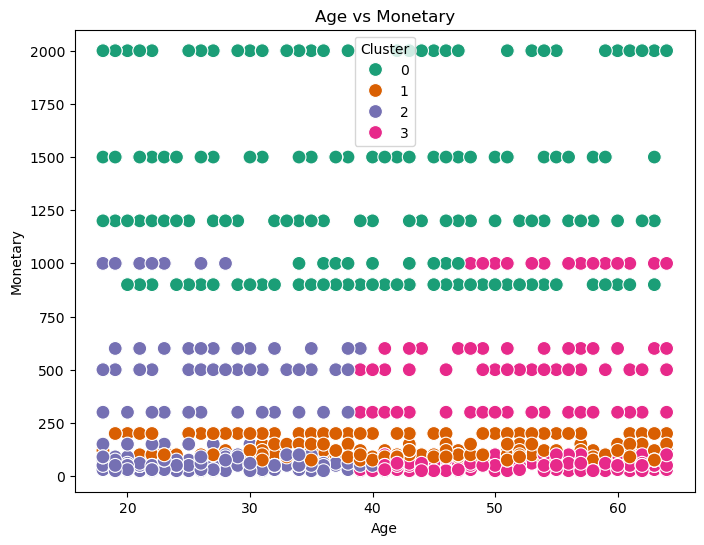

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer,
    x="Age",
    y="Monetary",
    hue="Cluster",
    palette="Dark2",
    s=100
)

plt.title("Age vs Monetary")
plt.show()

In [32]:
cluster_profile = customer.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile)

         Frequency     Monetary        Age
Cluster                                   
0         3.394737  1344.736842  39.631579
1         3.642570   131.345382  44.634538
2         1.741667   211.416667  26.829167
3         1.466431   233.056537  52.307420


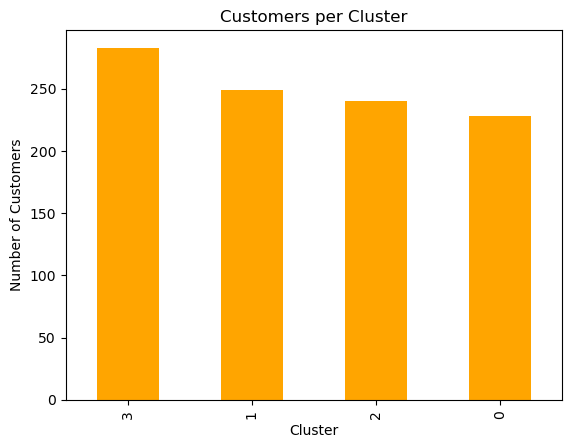

In [33]:
customer["Cluster"].value_counts().plot(kind="bar", color="orange")

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Shape:", df.shape)

print("Null Values")
print(df.isnull().sum())

print("Duplicate Rows")
print(df.duplicated().sum())

print("Data Types")
print(df.dtypes)

print("Summary Statistics")
print(df.describe())

Shape: (1000, 9)
Null Values
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Duplicate Rows
0
Data Types
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object
Summary Statistics
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.0

In [5]:
df.fillna(method="ffill", inplace=True)

print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


C:\Users\adil\AppData\Local\Temp\ipykernel_11988\2670923107.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (1000, 9)


In [7]:
df["Gender"] = df["Gender"].replace({
    "male":"Male",
    "MALE":"Male",
    "M":"Male",
    "female":"Female",
    "F":"Female"
})

df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[ns]


In [9]:
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [10]:
numeric_cols = ["Age","Quantity","Price per Unit","Total Amount"]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "Outliers")

Age : 0 Outliers
Quantity : 0 Outliers
Price per Unit : 0 Outliers
Total Amount : 0 Outliers


In [11]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [12]:
summary = pd.DataFrame({

"Rows":[1000,len(df)],
"Duplicates":[duplicates,df.duplicated().sum()],
"Null Values":[0,df.isnull().sum().sum()]

},

index=["Before Cleaning","After Cleaning"])

summary

,Rows,Duplicates,Null Values
Before Cleaning,1000,0,0
After Cleaning,1000,0,0


In [13]:
df.to_csv("Retail_Sales_Cleaned.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully
